# Function-on-Scalar Regression

In previous examples, we have examined regression when the outcome is a scalar value. But what if the outcome is a function rather than a scalar? This is an interesting challenge that has led to functional data analysis. In the described context, one can consider using function-on-scalar regression. While there are various ways to implement this regression approach in the literature (see Gunning et al.), we will review one method here that is straightforward to implement with estimating equations. This method is based on a series of regression models that can be pooled together.

For illustration, we use weather data collected from 35 locations averaged over the period from 1960 to 1994. Our interest is in modeling the average temperature (a function) by latitude (a scalar). The corresponding data for this example can be obtained from the R package `fda`.

## Setup

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt

import delicatessen as deli
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_regression
from delicatessen.sandwich import compute_confidence_bands
from delicatessen.utilities import spline

print("Versions")
print("NumPy:        ", np.__version__)
print("SciPy:        ", sp.__version__)
print("pandas:       ", pd.__version__)
print("matplotlib:   ", mp.__version__)
print("Delicatessen: ", deli.__version__)

Versions
NumPy:         2.3.5
SciPy:         1.16.3
pandas:        2.3.3
matplotlib:    3.10.8
Delicatessen:  4.2


The data was extracted as two parts: the average daily temperatures (in a 365 column by 35 row matrix) and the corresponding latitudes (a 1 column by 35 row vector). The following code loads these objects and does a bit of pre-processing for our question.

In [2]:
# Loading the data
dy = pd.read_csv("data/CanadianWeather_temps.csv", index_col=0)
dx = pd.read_csv("data/CanadianWeather_coord.csv", index_col=0)
dx['x'] = dx['x'] - np.mean(dx['x'])
dx['C'] = 1

# Converting to arrays for regression steps
y_matrix = np.asarray(dy)
X = np.asarray(dx[['C', 'x']])
y_s_vals = y_matrix.shape[1]
n_obs = y_matrix.shape[0]

## Function-on-Scalar Model

Letting $Y_i(d)$ denote the average temperature at day $d$ and $X_i$ indicate the latitude of the weather station. The regression model of interest in then the following function-on-scalar linear model
$$ E[Y_i (d)] = \beta_0(d) + \beta_1(d) X_i  \;\; \forall \; d \in \{1, 2, ..., 365\}$$
Note that the intercept and coefficients are defined for each $d$. Therefore, we have a whole collection of objects that need to be estimated.

One simple and popular method for function-on-scalar regression is to use a series of linear regression models. This is the approach we will take here. While we could fit separate linear models, save the coefficients, and then collate them; this approach makes it difficult to draw valid inference. Instead, we are going to jointly estimate all 365 linear regression models. This is a little computationally burdensome, but it can be somewhat mitigated by cleverly choosing the initial values. Alternatively, we could solve each regression independently and then stitch those results together at the end. Since it doesn't take too long, we take the simultaneous solving approach here.

In [3]:
def psi(theta):
    # Organizing coefficients that will be estimated
    beta0 = theta[:y_s_vals]  # Time-varying intercepts unique for d
    betaL = theta[y_s_vals:]  # Time-varying coefficients unique for d

    # Looping over all individual days for each regression
    ef_ols = []
    for d in range(y_s_vals):
        # Extract outcome vector for regression model
        y = y_matrix[:, d]

        # Setup corresponding coefficients for the day
        beta_s = np.asarray([beta0[d], betaL[d]])

        # Linear regression for temperature at day d
        ef_ols_d = ee_regression(theta=beta_s, y=y, X=X, model='linear')

        # Stacking together outputs
        ef_ols.append(ef_ols_d)

    # Returning stacked estimating functions
    return np.vstack(ef_ols)

In [4]:
# Using means as starting value for intercepts to speed up process
init_vals = list(np.mean(y_matrix, axis=0)) + [0., ]*y_s_vals

Given the defined collection of 365 linear regression models, we can now jointly solve them with `MEstimator` quite quickly (less than 30 seconds on my laptop)

In [5]:
estr = MEstimator(psi, init=init_vals)
estr.estimate()

As before, I mention the difficulty of inference. The main challenge here is that the parameter of interest is actually a collection of parameters (or more specifically, the functions $\beta_0(d)$ and $\beta_1(d)$ over a year-long period). In these settings, confidence intervals are not appropriate to report, as their coverage only corresponds to a singular parameter in each vector. Instead, we should report the confidence *bands*. These bands provide correct coverage for functions. See the References and corresponding Applied Examples for further details on confidence bands.

Here, we compute the confidence bands using the sup-t method. This requires that we have the complete sandwich covariance matrix for all our parameters of interest. This fact is what required us to simultaneously estimate all linear regression models and thus compute the correct sandwich covariance matrix. If we fit separate linear regression models, we would no longer be able to compute the confidence bands using this approach.

Once we've estimated the sandwich covariance, the confidence bands can be straightforwardly computed using `MEstimator.confidence_bands` but this function may take a bit of time again due to the dimension of the sandwich covariance matrix being quite large (a 730 by 730 matrix).

In [6]:
cb = estr.confidence_bands(method='supt', seed=3810841)

Examining the results (730 coefficients) is unlikely to be helpful. Instead, we can plot the $\beta(d)$ functions by $d$ to get a handle on our results. For statistical inference (i.e., expressing our uncertainty), we plot the aforementioned confidence bands as a shaded region around the point estimate of the function. Code for this is given below

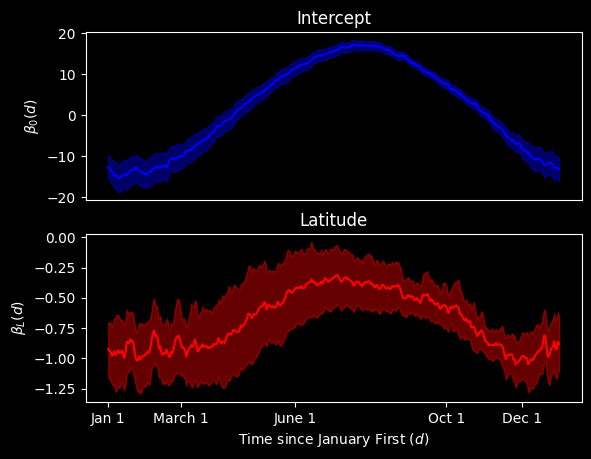

In [7]:
s_range = list(range(1, y_s_vals+1))

plt.subplot(211)
plt.plot(s_range, estr.theta[:y_s_vals], color='blue')
plt.fill_between(s_range, cb[:y_s_vals, 0], cb[:y_s_vals, 1],
                 alpha=0.4, color='blue')
plt.title("Intercept")
plt.ylabel(r"$\beta_0(d)$")
plt.xticks([])
plt.subplot(212)
plt.plot(s_range, estr.theta[y_s_vals:], color='red')
plt.fill_between(s_range, cb[y_s_vals:, 0], cb[y_s_vals:, 1],
                 alpha=0.4, color='red')
plt.title("Latitude")
plt.xlabel(r"Time since January First ($d$)")
plt.ylabel(r"$\beta_L(d)$")
plt.xticks([1, 60, 152, 274, 365-30],
           ['Jan 1', 'March 1', 'June 1', 'Oct 1', 'Dec 1'])
plt.show()

As we would expect, the Intercept plot indicates that temperatures steadily rise as time moves on from January, peaking a bit after June 1. Around September, these temperature decline. Regarding the latitude plot, we see that increasing latitude creates the largest temperature differential in the winter months. This temperature gap by latitude is closed somewhat during the summer months.

## Smoothing

Looking at this plot, you might notice that it is quite jagged. One might think that we can smooth over these jumps because they are most likely statistical noise. To do that, function-on-scalar regression generally takes the point estimates and applies some smoother at the end to even out this jagged-ness.

Since post-processing step provides a slight challenge to inference, we describe how the smoothing step can be done within the estimating equations themselves as an alternative. This directly provides inference for the smoothed functions.

In [8]:
x = np.asarray(dx['x'])

In [9]:
def create_spline_time(d):
    # Function to generate spline terms for a given day
    d_knots = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180,
               195, 210, 225, 245, 260, 275, 290, 305, 320, 335, 350]
    intercept = np.ones(shape=n_obs)
    linear_term = np.ones(shape=n_obs) * d
    spline_term = spline(linear_term, knots=d_knots,
                         power=2, restricted=True, normalized=True)
    return np.concatenate([intercept[:, None], linear_term[:, None], spline_term], axis=1)

In [10]:
def psi_smooth(theta):
    # Looping over all individual days for each regression
    ef_ols = 0
    for d in range(y_s_vals):
        # Extract outcome vector for regression model
        y = y_matrix[:, d]

        # Processing the design matrix
        time_matrix = create_spline_time(d=d)
        lati_matrix = time_matrix * x[:, None]
        design_matrix = np.hstack([time_matrix, lati_matrix])

        # Linear regression for temperature at day d
        ef_ols_d = ee_regression(theta=theta, y=y, X=design_matrix,
                                 model='linear')
        ef_ols = ef_ols + ef_ols_d

    # Returning stacked estimating functions
    return np.vstack(ef_ols)

In [11]:
init_vals = [np.mean(y_matrix), ] + [0., ]*23 + [0., ]*24

In [12]:
estr = MEstimator(psi_smooth, init=init_vals)
estr.estimate()
estr.print_results(subset=[0, 1, 2, 3, 4])

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          35 | No. Parameters:             48
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  -14.21     0.98   -14.46   -16.13   -12.28     0.00   155.09 
    0.01     0.02     0.51    -0.03     0.05     0.61     0.71 
   71.76    74.35     0.97   -73.96   217.49     0.33     1.58 
  496.32   110.57     4.49   279.61   713.04     0.00    17.09 
 -626.31    90.87    -6.89  -804.41  -448.20     0.00    37.41 


This code may take a little while to run (0.5-2 minutes), as the fitting process above is not the most efficient coding (we will return to this later).

As before, it is more helpful to look at a plot of the results rather than the numeric values for the coefficients. This process involves a bit more work on our part relative to the un-smoothed version. To simplify the following code, we define a function that computes the point and confidence bands for a given day based on the intercepts and coefficient

In [13]:
def predict_at_times(beta, covariance, days, x_value=0, include_intercept=True):
    # Processing the design matrix for predictions
    days = np.asarray(days)
    intercept = days*0 + 1
    d_knots = [15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180,
                   195, 210, 225, 245, 260, 275, 290, 305, 320, 335, 350]
    spline_term = spline(days, knots=d_knots,
                         power=2, restricted=True, normalized=True)
    time_matrix = np.concatenate([intercept[:, None], days[:, None], spline_term], axis=1)
    lati_matrix = time_matrix * x_value
    if include_intercept:
        design_matrix = np.hstack([time_matrix, lati_matrix])
    else:
        design_matrix = np.hstack([time_matrix*0, lati_matrix])

    # Generating point predictions
    yhat = np.dot(design_matrix, beta)

    # Computing the covariance matrix
    cov_p = design_matrix @ covariance @ design_matrix.T

    # Computing confidence bands
    cbands = compute_confidence_bands(yhat, covariance=cov_p,
                                      method='supt', seed=23210177)

    return yhat, cbands

Now we can create the range of days and then generate the predictions for the smoothed $\beta_0(d)$ and $\beta_1(d)$ separately

In [14]:
day_range = np.asarray(range(0, 365))

# Prediction for intercept
y0hat, cb0 = predict_at_times(days=day_range, beta=estr.theta, covariance=estr.variance)

# Prediction for latitude
y1hat, cb1 = predict_at_times(days=day_range, beta=estr.theta, covariance=estr.variance,
                              x_value=1, include_intercept=False)

C:\Users\pzivich\Documents\open-source\Delicatessen\delicatessen\sandwich.py:568: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  mvn = rng.multivariate_normal([0., ] * k, cov=covariance, size=n_draws)


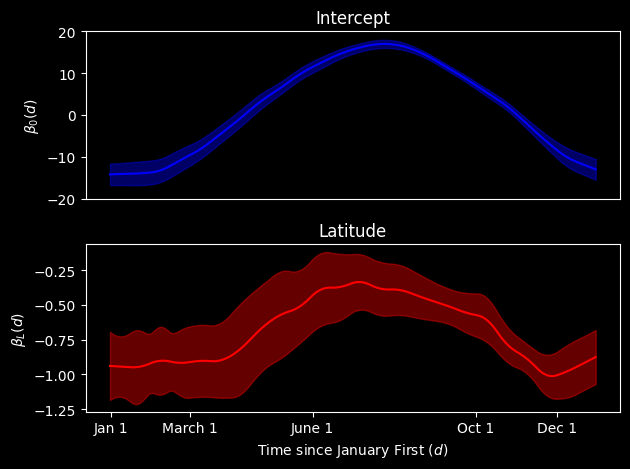

In [15]:
plt.subplot(211)
plt.plot(day_range, y0hat, color='blue')
plt.fill_between(day_range, cb0[:, 0], cb0[:, 1],
                 alpha=0.4, color='blue')
plt.title("Intercept")
plt.ylabel(r"$\beta_0(d)$")
plt.ylim([-20, 20])
plt.xticks([])
plt.subplot(212)
plt.plot(day_range, y1hat, color='red')
plt.fill_between(day_range, cb1[:, 0], cb1[:, 1],
                 alpha=0.4, color='red')
plt.title("Latitude")
plt.xlabel(r"Time since January First ($d$)")
plt.ylabel(r"$\beta_L(d)$")
plt.xticks([1, 60, 152, 274, 365-30],
           ['Jan 1', 'March 1', 'June 1', 'Oct 1', 'Dec 1'])
plt.tight_layout()
plt.show()

At the end of this process, we have a smoothed plot for each of our coefficients. We see the general shapes are the same but the bumpiness of the functions has been ironed out. Provided that we think the jaggedness from before was statistical noise (which seems reasonable to presume), we might prefer to present this plot.

The smoothing was controlled through our specification of the spline term. How many splines and where they are located control the smoothness of the corresponding regression coefficient functions. An advantage of this approach is that we can straightforwardly compute the confidence bands at the end of the process.

## Vectorized Smoothing

One difficult is that this process can take a bit of time to fit. While not a problem here, it can become more of an issue with larger data sets or more granular functions. To close this section, we review a vectorization of the previous estimating function. This is based on the underlying algorithm used for pooled logistic regression in `delicatessen`. To do this, we will (1) avoid creating a new design matrix for the day terms in the `psi` function, (2) avoid creating an individual-level design matrix for time, and (3) avoid having to loop over each day.

In [16]:
# Creating a spline design matrix for all unique times (note subsetting)
d_matrix = np.stack([create_spline_time(d=d)[0, :] for d in range(365)], axis=1).T

# Covariate design matrix (no intercept)
X = np.asarray(dx[['x', ]])

In [17]:
def psi_smooth_fast(theta):
    # Setup dimensions
    theta = np.asarray(theta)
    n, p = X.shape
    q = d_matrix.shape[1]
    alpha = theta[:q]
    Gamma = theta[q:].reshape(p, q)

    # Fitted values
    yt_hat = alpha @ d_matrix.T + X @ Gamma @ d_matrix.T

    # Residuals
    residual = y_matrix - yt_hat

    # Scores
    score_alpha = residual @ d_matrix
    score_gamma = np.einsum('nd,np,qd->npq', residual, X, d_matrix.T).reshape(n, -1)

    ef_vals = np.concatenate([score_alpha, score_gamma], axis=1)

    # Returning stacked estimating functions
    return ef_vals.T

In [18]:
init_vals = [np.mean(y_matrix), ] + [0., ]*23 + [0., ]*24

In [19]:
estr = MEstimator(psi_smooth_fast, init=init_vals)
estr.estimate()

In [20]:
# Repeating the plotting steps for the updated version
day_range = np.asarray(range(0, 365))
y0hat, cb0 = predict_at_times(days=day_range, beta=estr.theta, covariance=estr.variance)
y1hat, cb1 = predict_at_times(days=day_range, beta=estr.theta, covariance=estr.variance,
                              x_value=1, include_intercept=False)

C:\Users\pzivich\Documents\open-source\Delicatessen\delicatessen\sandwich.py:568: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  mvn = rng.multivariate_normal([0., ] * k, cov=covariance, size=n_draws)


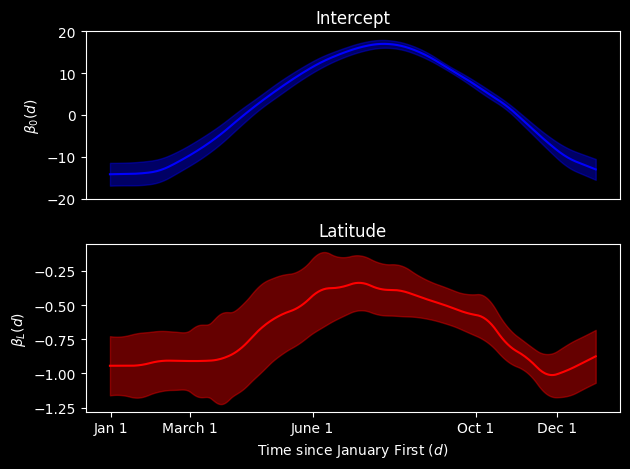

In [21]:
plt.subplot(211)
plt.plot(day_range, y0hat, color='blue')
plt.fill_between(day_range, cb0[:, 0], cb0[:, 1],
                 alpha=0.4, color='blue')
plt.title("Intercept")
plt.ylabel(r"$\beta_0(d)$")
plt.ylim([-20, 20])
plt.xticks([])
plt.subplot(212)
plt.plot(day_range, y1hat, color='red')
plt.fill_between(day_range, cb1[:, 0], cb1[:, 1],
                 alpha=0.4, color='red')
plt.title("Latitude")
plt.xlabel(r"Time since January First ($d$)")
plt.ylabel(r"$\beta_L(d)$")
plt.xticks([1, 60, 152, 274, 365-30],
           ['Jan 1', 'March 1', 'June 1', 'Oct 1', 'Dec 1'])
plt.tight_layout()
plt.show()

This vectorized version takes less than a second to run on my laptop, so we can really see the benefits of vectorization here. These benefits would compound as the dimension of either the function measurements or the number of observations increase. Therefore, the vectorization is probably the preferred implementation to use in practice.

You may notice that the functions look slightly different between the two approaches. This is not due to a difference in the algrebra between the approaches but is rather due to floating point errors. Some of the usual mathematical properties (associativity) no longer hold with floating point errors. In high-dimension problems (like this one), it can lead to an accumulation of floating point errors that can modify the results. This is a limit of computation that we persist with.

## References

Gunning E, Warmenhoven J, Harrison AJ, & Bargary N. (2024). *Functional Data Analysis in Biomechanics*. Springer.